In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [82]:
data = pd.read_csv("Mall_Customers.csv")
data.head()
data = data.drop(columns=["CustomerID", "Gender", "Age"])

In [83]:
X = data.values # 2D numpy array (not a pandas dataframe)

In [84]:
def distance(X, centroids):
    distances = []
    for i in range(len(centroids)):
        difference = X - centroids[i]
        sq_diff = difference ** 2
        sq_sum = np.sum(sq_diff)
        root = sq_sum ** 0.5
        distances.append(root) 
    
    return distances

In [ ]:
def kmeans(X, k, max_iterations=100):

    random_indices = np.random.choice(
        np.arange(len(X)),
        size=k,
        replace=False
    )

    centroids = X[random_indices]

    for iteration in range(max_iterations):

        assignments = []

        for i in range(len(X)):

            distances = distance(X[i], centroids)

            closest = distances.index(min(distances))

            assignments.append(closest)

        assignments = np.array(assignments)

        new_centroids = []

        for i in range(k):

            mask = assignments == i

            mean = np.mean(X[mask], axis=0)

            new_centroids.append(mean)

        new_centroids = np.array(new_centroids)

        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids


    return centroids, assignments, iteration + 1

In [86]:
k = 6
centroids, assignments, iterations = kmeans(X, k)

print("Final Centroids:")
print(centroids)

print("\nAssignments:")
print(assignments)

print("\nIterations completed:", iterations)

Final Centroids:
[[ 79.          16.59259259]
 [ 54.88607595  49.89873418]
 [ 25.72727273  79.36363636]
 [ 86.53846154  82.12820513]
 [109.7         22.        ]
 [ 26.30434783  20.91304348]]

Assignments:
[5 2 5 2 5 2 5 2 5 2 5 2 5 2 5 2 5 2 5 2 5 2 5 2 5 2 5 2 5 2 5 2 5 2 5 2 5
 2 5 2 5 2 5 1 5 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 1 3 0 3 0 3
 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 4 3 4 3 4
 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3]

Iterations completed: 8


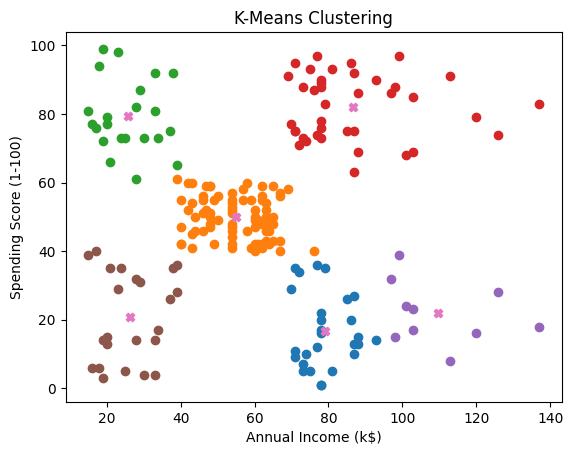

In [87]:
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Means Clustering")

for i in range(k):
    points = X[assignments == i]
    plt.scatter(points[:, 0], points[:, 1])
    
plt.scatter(centroids[:, 0], centroids[:, 1], marker="X")

In [88]:
def calculate_wcss(X, centroids, assignments):
    wcss = 0

    for i in range(len(X)):
        centroid = centroids[assignments[i]]

        difference = X[i] - centroid
        squared_difference = difference ** 2

        wcss += np.sum(squared_difference)

    return wcss

wcss = calculate_wcss(X, centroids, assignments)

print("WCSS:", wcss)

WCSS: 37455.98455516027


In [89]:
wcss_values = []

for k in range(1, 11):

    centroids, assignments, iterations = kmeans(X, k)

    wcss = calculate_wcss(X, centroids, assignments)

    wcss_values.append(wcss)

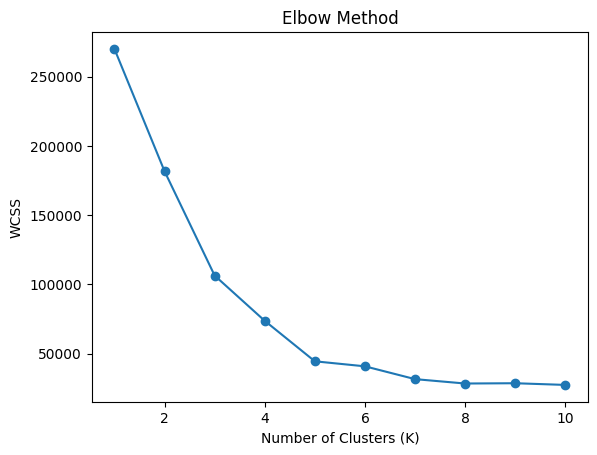

In [90]:
plt.plot(range(1, 11), wcss_values, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()